# Under-sampling and Feature Selection Pipeline
This notebook loads `datasets/BaseDataset.csv`, removes duplicates, tries two pipeline orders, and saves 3 final CSV files for top 9, 12, and 21 features.

# Imports

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.under_sampling import RandomUnderSampler

## Configuration

In [3]:
DATA_PATH = Path("../BaseDataset.csv")
OUTPUT_DIR = Path("")
TARGET_COL = "Diabetes_012"
TOP_K_VALUES = [9, 12, 21]
SCORING = "f1_macro"
CV_SPLITS = 5

## Load Dataset

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Original shape: {df.shape}")

Original shape: (253680, 22)


## Remove duplicates

In [5]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Duplicates removed: {before - after}")
print(f"New shape: {df.shape}")

if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not found in dataset columns.")

print("\nClass distribution after de-duplication:")
print(df[TARGET_COL].value_counts().sort_index())

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

Duplicates removed: 23899
New shape: (229781, 22)

Class distribution after de-duplication:
Diabetes_012
0.0    190055
1.0      4629
2.0     35097
Name: count, dtype: int64


## Split

In [6]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(160846, 21) (22978, 21) (45957, 21)


## Feature Selection then Under-sampling

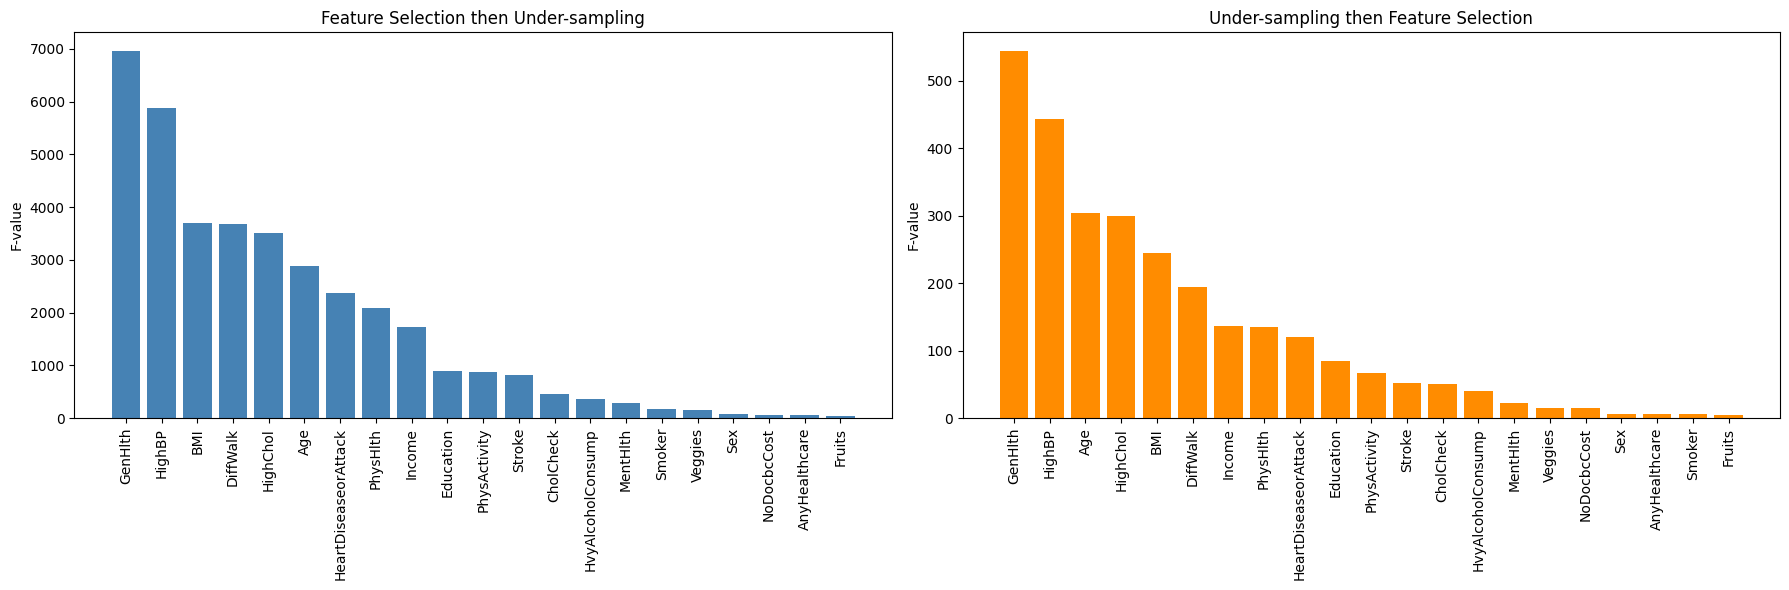

In [26]:
# Left plot: Feature selection on original training data
selector_all = SelectKBest(score_func=f_classif, k="all")
selector_all.fit(X_train, y_train)
scores = selector_all.scores_
features = X_train.columns
indices = np.argsort(scores)[::-1]

# Right plot: Under-sample first, then feature selection
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
selector_all_under = SelectKBest(score_func=f_classif, k="all")
selector_all_under.fit(X_train_under, y_train_under)
scores_under = selector_all_under.scores_
features_under = X_train_under.columns
indices_under = np.argsort(scores_under)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

axes[0].bar(range(len(scores)), scores[indices], color="steelblue")
axes[0].set_xticks(range(len(scores)))
axes[0].set_xticklabels(features[indices], rotation=90)
axes[0].set_title("Feature Selection then Under-sampling")
axes[0].set_ylabel("F-value")

axes[1].bar(range(len(scores_under)), scores_under[indices_under], color="darkorange")
axes[1].set_xticks(range(len(scores_under)))
axes[1].set_xticklabels(features_under[indices_under], rotation=90)
axes[1].set_title("Under-sampling then Feature Selection")
axes[1].set_ylabel("F-value")

plt.tight_layout()
plt.show()



## Class Distribution

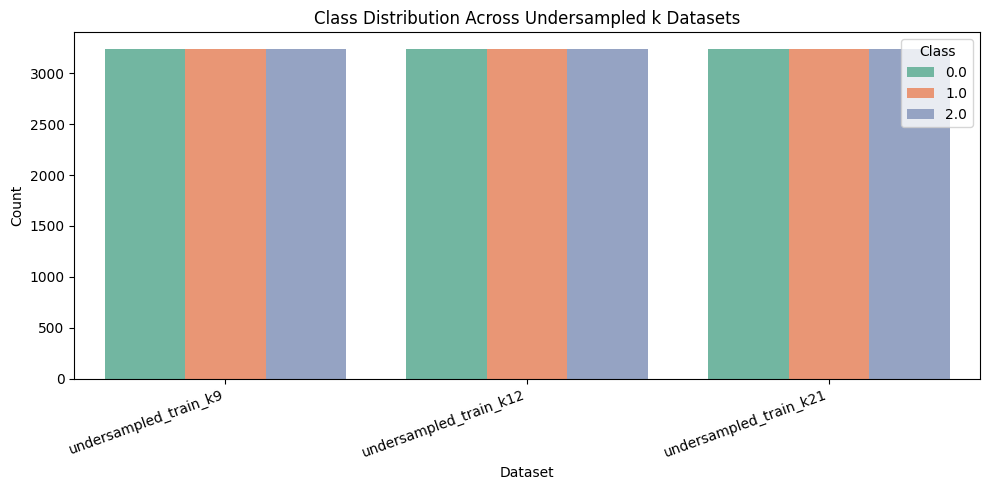

In [11]:
# Build class counts for undersampled train distributions of selected-k feature sets only
class_dist_rows = []

for k in TOP_K_VALUES:
    selector_k = SelectKBest(score_func=f_classif, k=k)
    selector_k.fit(X_train, y_train)

    X_train_k = pd.DataFrame(
        selector_k.transform(X_train),
        columns=X_train.columns[selector_k.get_support()],
        index=X_train.index,
    )

    rus_k = RandomUnderSampler(random_state=42)
    _, y_train_k_under = rus_k.fit_resample(X_train_k, y_train)

    counts_k = y_train_k_under.value_counts().sort_index()
    for class_label, count in counts_k.items():
        class_dist_rows.append(
            {
                "dataset": f"undersampled_train_k{k}",
                "class": str(class_label),
                "count": int(count),
            }
        )

class_dist_df = pd.DataFrame(class_dist_rows)

if class_dist_df.empty:
    raise ValueError("Class distribution table is empty. Check earlier preprocessing cells.")

plt.figure(figsize=(10, 5))
sns.barplot(
    data=class_dist_df,
    x="dataset",
    y="count",
    hue="class",
    palette="Set2",
)
plt.title("Class Distribution Across Undersampled k Datasets")
plt.xlabel("Dataset")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

## Feature Distribution

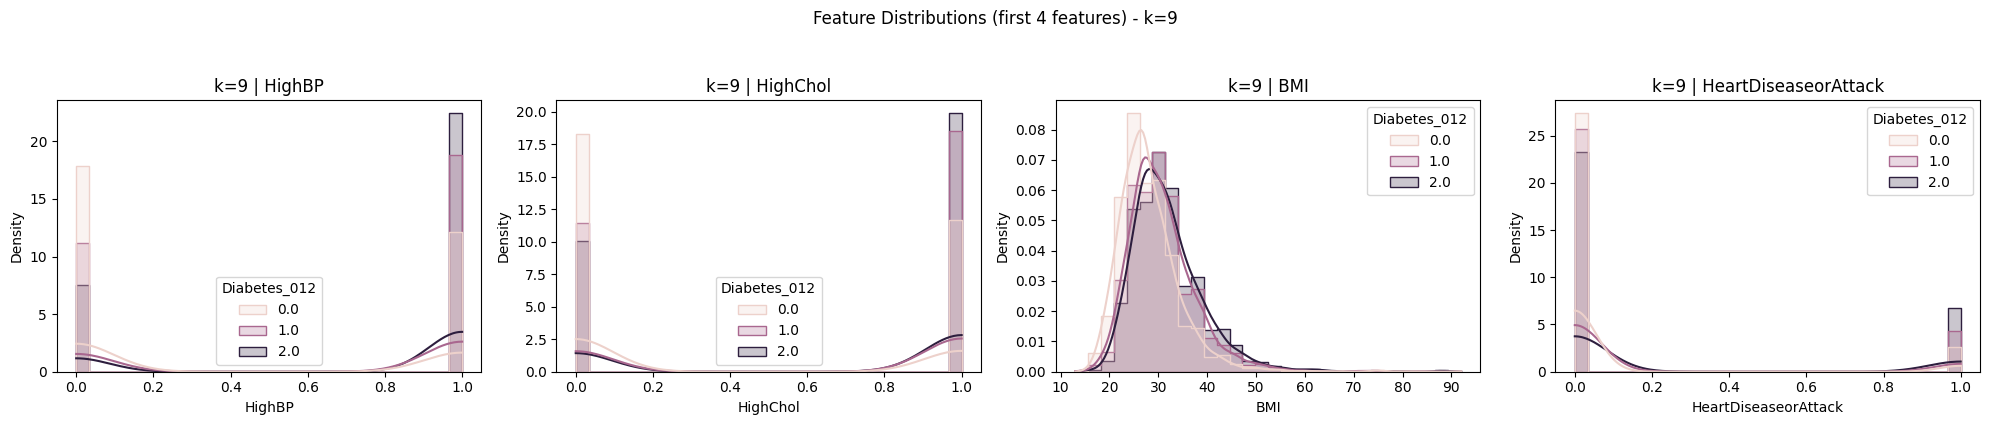

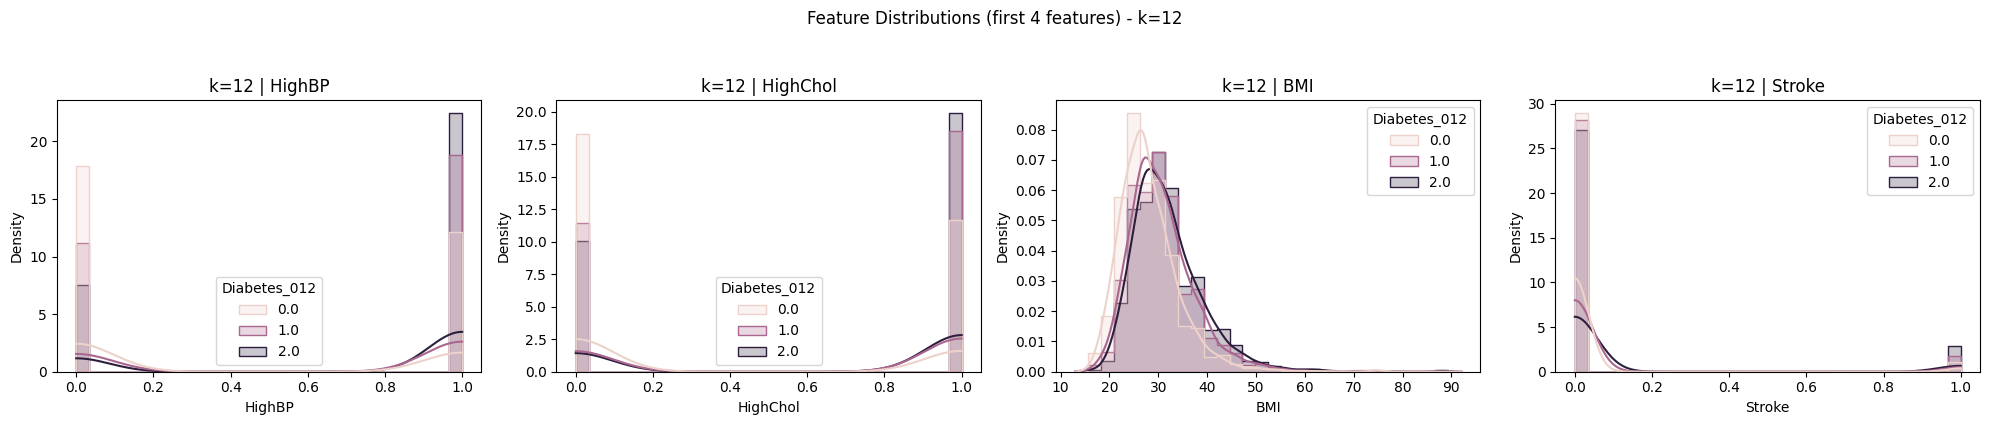

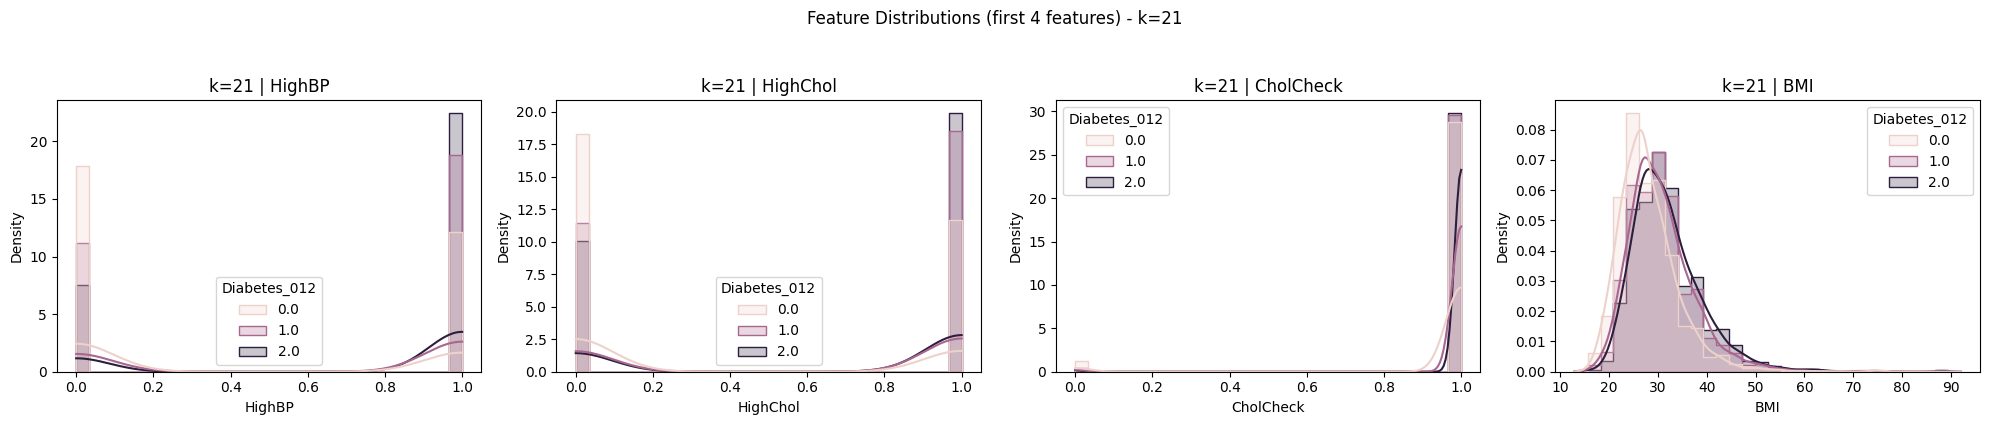

In [12]:
# Build datasets for undersampled train distributions of selected-k feature sets only
datasets = {}

for k in TOP_K_VALUES:
    selector_k = SelectKBest(score_func=f_classif, k=k)
    selector_k.fit(X_train, y_train)
    selected_cols = X_train.columns[selector_k.get_support()]

    X_train_k = pd.DataFrame(
        selector_k.transform(X_train), columns=selected_cols, index=X_train.index
    )

    rus_k = RandomUnderSampler(random_state=42)
    X_train_k_under, y_train_k_under = rus_k.fit_resample(X_train_k, y_train)

    train_k_df = X_train_k_under.copy()
    train_k_df[TARGET_COL] = y_train_k_under.values
    datasets[k] = {
        "df": train_k_df,
        "target_col": TARGET_COL,
    }

for k in TOP_K_VALUES:
    item = datasets[k]
    dset = item["df"]
    target_col = item["target_col"]
    feature_cols = [c for c in dset.columns if c != target_col][:4]

    if len(feature_cols) == 0:
        print(f"No feature columns found in dataset k={k}.")
        continue

    n = len(feature_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, feature_cols):
        sns.histplot(
            data=dset,
            x=col,
            hue=target_col,
            bins=30,
            kde=True,
            ax=ax,
            element="step",
            stat="density",
            common_norm=False,
        )
        ax.set_title(f"k={k} | {col}")

    fig.suptitle(f"Feature Distributions (first {n} features) - k={k}", y=1.05)
    plt.tight_layout()
    plt.show()

## Save CSVs: Feature Selection First (k=9,12,21)

In [7]:
# Apply feature selection using train split, under-sample train only, and save train/val/test CSVs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

saved_files = []
for k in [9, 12, 21]:
    selector_k = SelectKBest(score_func=f_classif, k=k)
    selector_k.fit(X_train, y_train)
    selected_cols = X_train.columns[selector_k.get_support()]

    X_train_k = pd.DataFrame(
        selector_k.transform(X_train), columns=selected_cols, index=X_train.index
    )
    X_val_k = pd.DataFrame(
        selector_k.transform(X_val), columns=selected_cols, index=X_val.index
    )
    X_test_k = pd.DataFrame(
        selector_k.transform(X_test), columns=selected_cols, index=X_test.index
    )

    rus_k = RandomUnderSampler(random_state=42)
    X_train_k_under, y_train_k_under = rus_k.fit_resample(X_train_k, y_train)

    train_df = X_train_k_under.copy()
    train_df[TARGET_COL] = y_train_k_under.values

    val_df = X_val_k.copy()
    val_df[TARGET_COL] = y_val.values

    test_df = X_test_k.copy()
    test_df[TARGET_COL] = y_test.values

    # Keep original filename pattern for train outputs
    train_path = OUTPUT_DIR / f"undersampling_train_k{k}.csv"
    val_path = OUTPUT_DIR / f"undersampling_val_k{k}.csv"
    test_path = OUTPUT_DIR / f"undersampling_test_k{k}.csv"

    train_df.to_csv(train_path, index=False)
    val_df.to_csv(val_path, index=False)
    test_df.to_csv(test_path, index=False)

    saved_files.extend([
        (str(train_path), train_df.shape),
        (str(val_path), val_df.shape),
        (str(test_path), test_df.shape),
    ])

print("Saved files with shapes:")
for file_path, shape in saved_files:
    print(f"- {file_path}: {shape}")

Saved files with shapes:
- undersampling_train_k9.csv: (9720, 10)
- undersampling_val_k9.csv: (22978, 10)
- undersampling_test_k9.csv: (45957, 10)
- undersampling_train_k12.csv: (9720, 13)
- undersampling_val_k12.csv: (22978, 13)
- undersampling_test_k12.csv: (45957, 13)
- undersampling_train_k21.csv: (9720, 22)
- undersampling_val_k21.csv: (22978, 22)
- undersampling_test_k21.csv: (45957, 22)
